# Scheme Trigger Rate

Trigger rate as a function of the summed-ADC threshold, using the pGRAMS trigger scheme:

- **32 trigger channels** (0-31) from 8 cells; channels 32-35 (one per cell on MB1/MB2/MB3-mid) are excluded by mapping choice.
- Per-event summed-ADC peaks are measured **per channel** (4 SiPMs per channel, baseline-subtracted, clipped to the summed dynamic range).
- A trigger fires when, within any rolling window of 6 consecutive trigger-channels (0-5, 1-6, ..., 26-31), at least 2 channels cross the threshold (multiplicity = 2).

Referenced modules:
- [scripts/light_config.py](../scripts/light_config.py) — channel map + `fires_trigger`
- [scripts/extract_df.py](../scripts/extract_df.py) — stores `channel_peak_adc` per event


In [2]:
import numpy as np
import pickle
import os
import seaborn as sns
colors = sns.color_palette("colorblind")
import matplotlib.pyplot as plt
plt.style.use('~/latex-cm.mplstyle')

import sys
sys.path.append('/nevis/wanaka/share/standon/GRAMS/GramsOccupancy')
from scripts.config import MAPS_DIR, PARTICLE_DICT, DATA_DIR, LOCATION, DATE
from scripts.extract_df import (
    extract_all_events,
    BASELINE_ADC, ADC_MAX,
    SUMMED_BASELINE_ADC, SUMMED_ADC_MAX,
)
from scripts.light_config import (
    N_CHANNELS, N_TRIGGER_CHANNELS, NON_TRIGGER_CHANNELS,
    TRIGGER_WINDOW_SIZE, TRIGGER_MULTIPLICITY,
    CELL_CHANNELS, CHANNEL_TO_MB, CHANNEL_IS_VUV,
    trigger_windows, fires_trigger,
)

SUMMED_DYNAMIC_RANGE = SUMMED_ADC_MAX - SUMMED_BASELINE_ADC  # 8192
particle_names = {k: v[0] for k, v in PARTICLE_DICT.items()}

print(f"Trigger scheme: multiplicity={TRIGGER_MULTIPLICITY}, "
      f"window={TRIGGER_WINDOW_SIZE}, "
      f"{N_TRIGGER_CHANNELS} trigger channels, "
      f"{len(trigger_windows())} rolling windows.")


Trigger scheme: multiplicity=2, window=5, 32 trigger channels, 28 rolling windows.


In [3]:
# Load per-particle weights (events -> Hz).
weights_path = os.path.join(MAPS_DIR, 'pkl', 'weights.pkl')
with open(weights_path, 'rb') as f:
    weights = pickle.load(f)
for p, w in weights.items():
    print(f"  {p}: w={w['w']:.3e} Hz/event")


  neutro: w=4.385e-02 Hz/event
  proton: w=7.326e-03 Hz/event
  he---4: w=4.703e-04 Hz/event
  muplus: w=1.066e-03 Hz/event
  mumins: w=9.633e-04 Hz/event
  electr: w=1.931e-02 Hz/event
  positr: w=1.123e-02 Hz/event
  photon: w=4.943e-01 Hz/event


In [4]:
# Load per-event DataFrame. Older parquet caches do not yet include
# `channel_peak_adc` (a list of 36 per-channel summed-ADC peaks). If the
# column is missing, the next cell will fall back to reading OpDetWaveforms
# directly from the opdetsim ROOT files. To rebuild the cache with the new
# column (recommended once GramsSim is done writing):
#     python scripts/extract_df.py --force
events_df = extract_all_events()
print(f"Loaded {len(events_df)} events across {events_df['particle'].nunique()} particles")
has_col = 'channel_peak_adc' in events_df.columns
print(f"channel_peak_adc in events_df: {has_col}"
      + ("" if has_col else "  -> will fall back to reading *_opdetsim.root directly"))
events_df.head(2)


[CACHE] Loading from /nevis/wanaka/data/standon/GramsOccupancy/tucson_2025_8_31_maps/pkl/events.parquet
Loaded 80000 events across 8 particles
channel_peak_adc in events_df: True


,event_index,n_lar_hits,total_scint_photons,total_cer_photons,total_ionization_energy,primary_energy,primary_pdg,primary_px,primary_py,primary_pz,dominant_daughter_process,daughter_processes,containment,channel_peak_adc,peak_adc,particle
0,0,0,0,0,0.000000,0.055653,22,-0.003998,-0.001106,-0.003710,None,phot,inactive,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0,photon
1,1,18,7940,0,0.157758,0.169131,22,0.001543,-0.012511,0.011275,compt,"compt,compt,compt,compt,compt,phot",incomplete,"[0, 0, 0, 0, 364, 364, 364, 0, 0, 0, 0, 0, 0, ...",594,photon


In [5]:
# Build (N, 36) per-particle channel-peak arrays.
#
# Preferred path: use the `channel_peak_adc` column from the parquet cache.
# Fallback (when parquet pre-dates that column, or GramsSim is still writing):
# read OpDetWaveforms directly from whichever `*_opdetsim.root` files already
# exist on disk. Any particle whose file is missing or whose tree can't be
# read is skipped.
import os as _os

SIM_DIR = _os.path.join(DATA_DIR, f"{LOCATION}_{DATE}_maps", "sim")

# Ensure the GramsSim dictionary is loaded so cppyy can iterate
# map<int, grams::OpDetWaveform>. Safe to call repeatedly.
from scripts.config import GRAMSSIM_DICTIONARY as _GS_DICT
import ROOT as _ROOT
_ROOT.gSystem.Load(_GS_DICT)


def _extract_channel_peaks_from_root(particle):
    from scripts.extract_df import BASELINE_ADC, SUMMED_DYNAMIC_RANGE
    from scripts.light_config import opdet_to_channel
    path = _os.path.join(SIM_DIR, f"{LOCATION}_{particle}_opdetsim.root")
    if not _os.path.exists(path):
        return None
    f = _ROOT.TFile.Open(path)
    if not f or f.IsZombie():
        return None
    tree = f.Get("OpDetSim")
    if not tree:
        f.Close()
        return None
    n = tree.GetEntries()
    arr = np.zeros((n, N_CHANNELS), dtype=np.int32)
    try:
        for i in range(n):
            tree.GetEntry(i)
            channel_wfs = {}
            for readoutID, waveform in tree.OpDetWaveforms:
                vec = waveform.Digital()
                if vec.size() == 0:
                    continue
                wf = np.asarray(vec, dtype=np.int64) - BASELINE_ADC
                ch = opdet_to_channel(readoutID)
                existing = channel_wfs.get(ch)
                if existing is None:
                    channel_wfs[ch] = wf.copy()
                else:
                    ml = min(existing.size, wf.size)
                    existing[:ml] += wf[:ml]
            for ch, wf in channel_wfs.items():
                peak = int(wf.max())
                if peak > SUMMED_DYNAMIC_RANGE:
                    peak = SUMMED_DYNAMIC_RANGE
                elif peak < 0:
                    peak = 0
                arr[i, ch] = peak
    finally:
        f.Close()
    return arr


def _stack_from_df(sub_df):
    vals = sub_df['channel_peak_adc'].tolist()
    return np.asarray([v if v is not None else [0]*N_CHANNELS for v in vals],
                      dtype=np.int32)


channel_peaks_by_particle = {}
use_df = 'channel_peak_adc' in events_df.columns

for p in PARTICLE_DICT.keys():
    if use_df:
        arr = _stack_from_df(events_df[events_df['particle'] == p])
        src = 'parquet'
    else:
        arr = _extract_channel_peaks_from_root(p)
        src = 'root'
    if arr is None or len(arr) == 0:
        print(f"  [SKIP] {p}: no data available")
        continue
    channel_peaks_by_particle[p] = arr
    print(f"  [{src}] {p}: shape={arr.shape}, max={int(arr.max())}")

if not channel_peaks_by_particle:
    raise RuntimeError("no particles have usable channel-peak data yet")


  [parquet] neutro: shape=(10000, 36), max=8192
  [parquet] proton: shape=(10000, 36), max=8192
  [parquet] he---4: shape=(10000, 36), max=8192
  [parquet] muplus: shape=(10000, 36), max=8192
  [parquet] mumins: shape=(10000, 36), max=8192
  [parquet] electr: shape=(10000, 36), max=8192
  [parquet] positr: shape=(10000, 36), max=8192
  [parquet] photon: shape=(10000, 36), max=8192


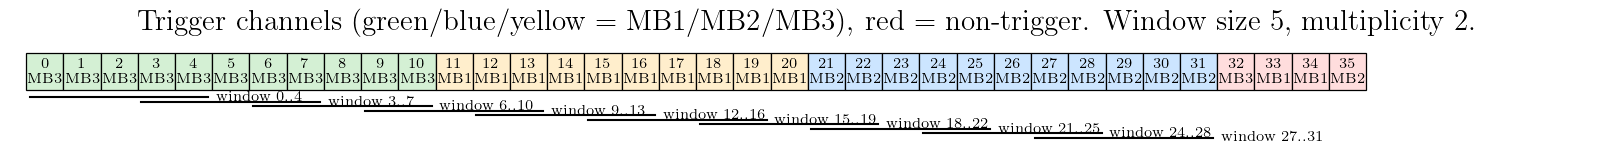

In [6]:
# Visualize the trigger scheme: channel index (0-31) laid out along the
# S-snake cell ordering, shaded by motherboard; non-trigger channels (32-35)
# marked separately.
fig, ax = plt.subplots(figsize=(11, 4))

mb_colors = {'MB1': '#ffeecc', 'MB2': '#cce5ff', 'MB3': '#d4f0d4'}
for ch in range(N_CHANNELS):
    is_trig = ch not in NON_TRIGGER_CHANNELS
    mb = CHANNEL_TO_MB[ch]
    facecolor = mb_colors[mb] if is_trig else '#ffdddd'
    ax.add_patch(plt.Rectangle((ch - 0.5, 0), 1, 1,
                               facecolor=facecolor, edgecolor='black', lw=0.6))
    label = f"{ch}\n{mb}"
    ax.text(ch, 0.5, label, ha='center', va='center', fontsize=7)

# Draw a few rolling windows at the bottom as brackets
windows = trigger_windows()
for i, w in enumerate(windows[::3]):  # every 3rd window, for clarity
    y = -0.2 - 0.12 * i
    ax.plot([w[0] - 0.4, w[-1] + 0.4], [y, y], 'k-', lw=1)
    ax.text(w[-1] + 0.6, y, f"window {w[0]}..{w[-1]}", va='center', fontsize=7)

ax.set_xlim(-1, N_CHANNELS + 6)
ax.set_ylim(-1.6, 1.3)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title(f"Trigger channels (green/blue/yellow = MB1/MB2/MB3), "
             f"red = non-trigger. Window size {TRIGGER_WINDOW_SIZE}, multiplicity {TRIGGER_MULTIPLICITY}.")
plt.tight_layout()
plt.show()


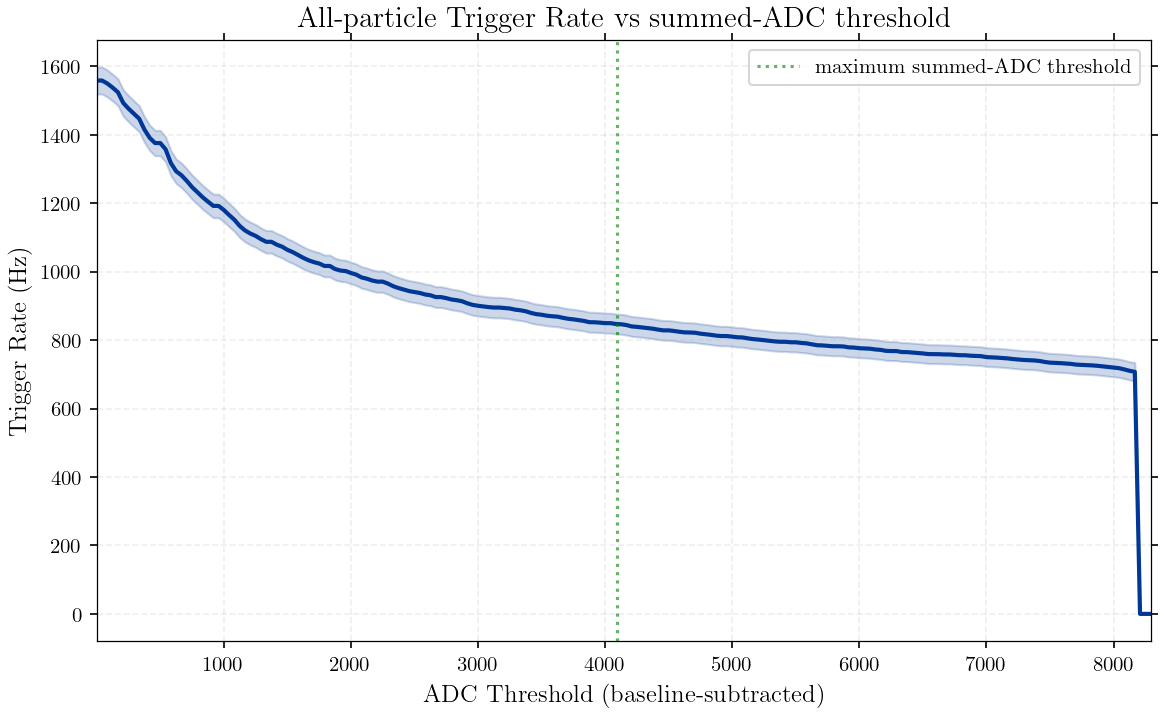

In [13]:
# Total trigger rate vs summed-ADC threshold (all particles combined).
thresholds_adc = np.linspace(1, SUMMED_DYNAMIC_RANGE + 100, 200).astype(int)

# Precompute event-count vs threshold per particle (vectorized trigger).
fired_counts_by_particle = {}
for p, peaks in channel_peaks_by_particle.items():
    # peaks: (N, 36) int32
    counts = np.empty(len(thresholds_adc), dtype=np.int64)
    for i, T in enumerate(thresholds_adc):
        counts[i] = int(fires_trigger(peaks, T).sum())
    fired_counts_by_particle[p] = counts

trigger_rates_all = np.zeros_like(thresholds_adc, dtype=np.float64)
for p, counts in fired_counts_by_particle.items():
    trigger_rates_all += counts * weights[p]['w']

GREEN_THRESHOLD = 2048 * 2
RED_THRESHOLD = 2048 * 4

plt.figure(figsize=(8, 5))
plt.plot(thresholds_adc, trigger_rates_all, "-", color="#003898", linewidth=2)
plt.fill_between(
    thresholds_adc,
    np.maximum(0, trigger_rates_all - np.sqrt(np.maximum(trigger_rates_all, 0))),
    trigger_rates_all + np.sqrt(np.maximum(trigger_rates_all, 0)),
    color="#003898", alpha=0.2,
)
plt.axvline(GREEN_THRESHOLD, color="g", ls=":", lw=1.5, alpha=0.6,
            label='maximum summed-ADC threshold')
# plt.axvline(RED_THRESHOLD, color="r", ls=":", lw=1.5, alpha=0.6,
#             label='four-channel saturation')
plt.xlim(1, SUMMED_DYNAMIC_RANGE + 100)
plt.xlabel("ADC Threshold (baseline-subtracted)")
plt.ylabel("Trigger Rate (Hz)")
plt.title(f"All-particle Trigger Rate vs summed-ADC threshold")
plt.grid(True, ls="--", alpha=0.2)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


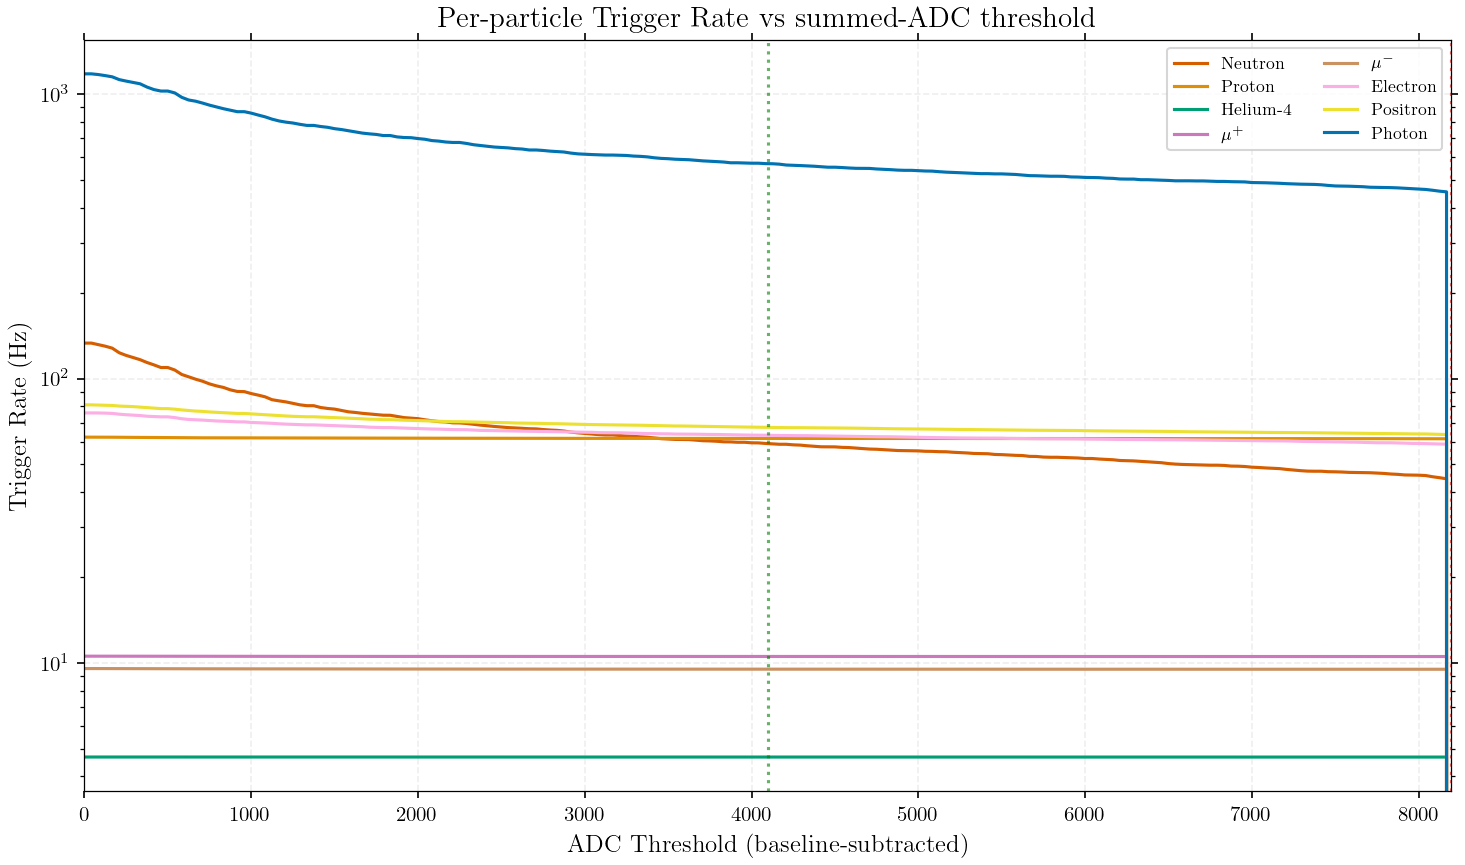

In [15]:
# Per-particle trigger-rate curves.
plt.figure(figsize=(10, 6))
particle_colors = {
    "photon": colors[0], "proton": colors[1], "he---4": colors[2], "neutro": colors[3],
    "muplus": colors[4], "mumins": colors[5], "electr": colors[6], "positr": colors[8],
}

for particle in PARTICLE_DICT.keys():
    counts = fired_counts_by_particle[particle]
    w = weights[particle]['w']
    rates = counts * w
    plt.plot(thresholds_adc, rates, "-",
             color=particle_colors.get(particle, 'k'),
             label=particle_names.get(particle, particle))

plt.axvline(GREEN_THRESHOLD, color="g", ls=":", lw=1.5, alpha=0.6)
plt.axvline(RED_THRESHOLD, color="r", ls=":", lw=1.5, alpha=0.6)
plt.xlim(0, SUMMED_DYNAMIC_RANGE)
plt.xlabel("ADC Threshold (baseline-subtracted)")
plt.ylabel("Trigger Rate (Hz)")
plt.title("Per-particle Trigger Rate vs summed-ADC threshold")
plt.semilogy()
plt.legend(fontsize=8, ncol=2)
plt.grid(True, ls="--", alpha=0.2)
plt.tight_layout()
plt.show()


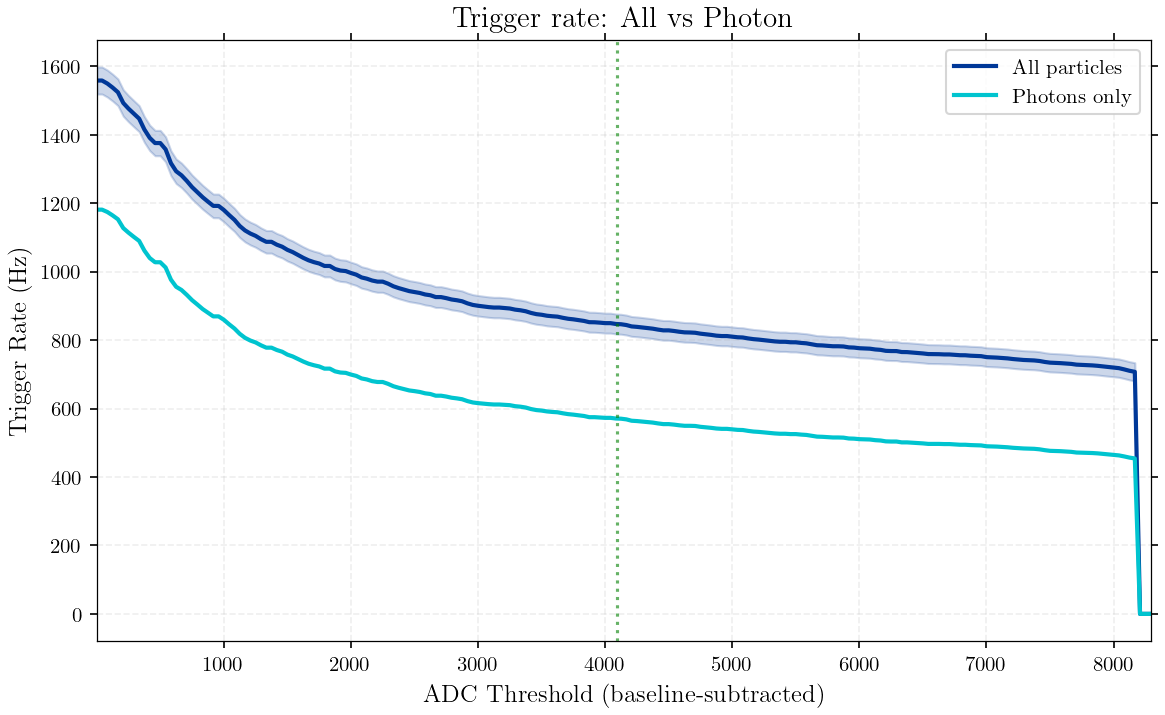

In [19]:
# Comparison: all particles vs photons only under the scheme.
trigger_rates_photon = fired_counts_by_particle['photon'] * weights['photon']['w']

plt.figure(figsize=(8, 5))
plt.plot(thresholds_adc, trigger_rates_all, "-", color="#003898", linewidth=2,
         label="All particles")
plt.fill_between(
    thresholds_adc,
    np.maximum(0, trigger_rates_all - np.sqrt(np.maximum(trigger_rates_all, 0))),
    trigger_rates_all + np.sqrt(np.maximum(trigger_rates_all, 0)),
    color="#003898", alpha=0.2,
)
plt.plot(thresholds_adc, trigger_rates_photon, "-", color="#00C4CF", linewidth=2,
         label="Photons only")
plt.axvline(GREEN_THRESHOLD, color="g", ls=":", lw=1.5, alpha=0.6)
# plt.axvline(RED_THRESHOLD, color="r", ls=":", lw=1.5, alpha=0.6)
plt.xlim(1, SUMMED_DYNAMIC_RANGE + 100)
plt.xlabel("ADC Threshold (baseline-subtracted)")
plt.ylabel("Trigger Rate (Hz)")
plt.title(f"Trigger rate: All vs Photon")
plt.legend()
plt.grid(True, ls="--", alpha=0.2)
plt.tight_layout()
plt.show()


In [10]:
# Sanity check: of events that have *any* channel activity (non-zero summed-ADC
# peak in at least one channel), what fraction fire the trigger? If this stays
# ~1.0 across a wide threshold range, the scheme isn't actually suppressing
# anything and the "rate didn't change" observation is explained by saturation
# (most events peg the summed-ADC ceiling on multiple channels).

def _fraction_triggered_given_hit(peaks, threshold):
    """Return (n_with_hits, n_fired, frac) at a given threshold.
    "With hits" = at least one channel has a non-zero peak."""
    has_hit = (peaks > 0).any(axis=1)
    n_hit = int(has_hit.sum())
    if n_hit == 0:
        return 0, 0, float('nan')
    fired = fires_trigger(peaks, threshold)
    n_fired = int((fired & has_hit).sum())
    return n_hit, n_fired, n_fired / n_hit


probe_thresholds = [1, 100, 500, GREEN_THRESHOLD, RED_THRESHOLD, SUMMED_DYNAMIC_RANGE]

# Combined across all particles (unweighted event counts).
all_peaks = np.concatenate(list(channel_peaks_by_particle.values()), axis=0)
print(f"Combined events (unweighted): {len(all_peaks)}")
has_hit_all = (all_peaks > 0).any(axis=1)
print(f"  events with any channel hit: {int(has_hit_all.sum())} "
      f"({100*has_hit_all.mean():.1f}%)")
print()
print(f"{'threshold':>10}  {'n_with_hits':>12}  {'n_fired':>10}  {'frac triggered | hit':>22}")
for T in probe_thresholds:
    n_hit, n_fired, frac = _fraction_triggered_given_hit(all_peaks, T)
    print(f"{T:>10}  {n_hit:>12}  {n_fired:>10}  {frac:>22.4f}")

print()
print("Per-particle fraction triggered | event has a hit:")
print(f"{'particle':>10}  " + "  ".join(f"T={T:>5}" for T in probe_thresholds))
for p, peaks in channel_peaks_by_particle.items():
    row = [f"{p:>10}"]
    for T in probe_thresholds:
        _, _, frac = _fraction_triggered_given_hit(peaks, T)
        row.append(f"{frac:>7.4f}")
    print("  ".join(row))


Combined events (unweighted): 80000
  events with any channel hit: 54960 (68.7%)

 threshold   n_with_hits     n_fired    frac triggered | hit
         1         54960       54843                  0.9979
       100         54960       54696                  0.9952
       500         54960       53602                  0.9753
      2048         54960       50959                  0.9272
      8192         54960       48724                  0.8865
      8192         54960       48724                  0.8865

Per-particle fraction triggered | event has a hit:
  particle  T=    1  T=  100  T=  500  T= 2048  T= 8192  T= 8192
    neutro   0.9826   0.9583   0.8063   0.5279   0.3274   0.3274
    proton   0.9999   0.9994   0.9966   0.9911   0.9868   0.9868
    he---4   1.0000   1.0000   1.0000   0.9999   0.9996   0.9996
    muplus   1.0000   1.0000   0.9996   0.9978   0.9971   0.9971
    mumins   0.9998   0.9996   0.9986   0.9957   0.9941   0.9941
    electr   0.9970   0.9952   0.9657   0.8763   